<a href="https://colab.research.google.com/github/pradeep-ramola/AI-ML/blob/main/ML-Projects/BuffaloInventory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


First i need to understand what the data is before exploring the data
1. what does the data represent in general
2. what are the columns
3. Which one i find interesting / what can i solve with this data
4. Can i find out the relation between the columns [target and features]


In [ ]:
# link = "https://drive.google.com/file/d/1eRWzXKjH6ZlrMWfr0KC7JeLWG5BcOBlI/view?usp=drive_link"
link = '/content/drive/MyDrive/Colab Notebooks/Tree_Inventory_20250908.csv'

import numpy as np
import pandas as pd
# threw error because of the column 23 has mixed data
# df= pd.read_csv(link)
df = pd.read_csv(link, low_memory=False)
# pd.set_option('display.max_columns', None)
# print(df.head())
print(df.columns)


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Colab Notebooks/Tree_Inventory_20250908.csv'

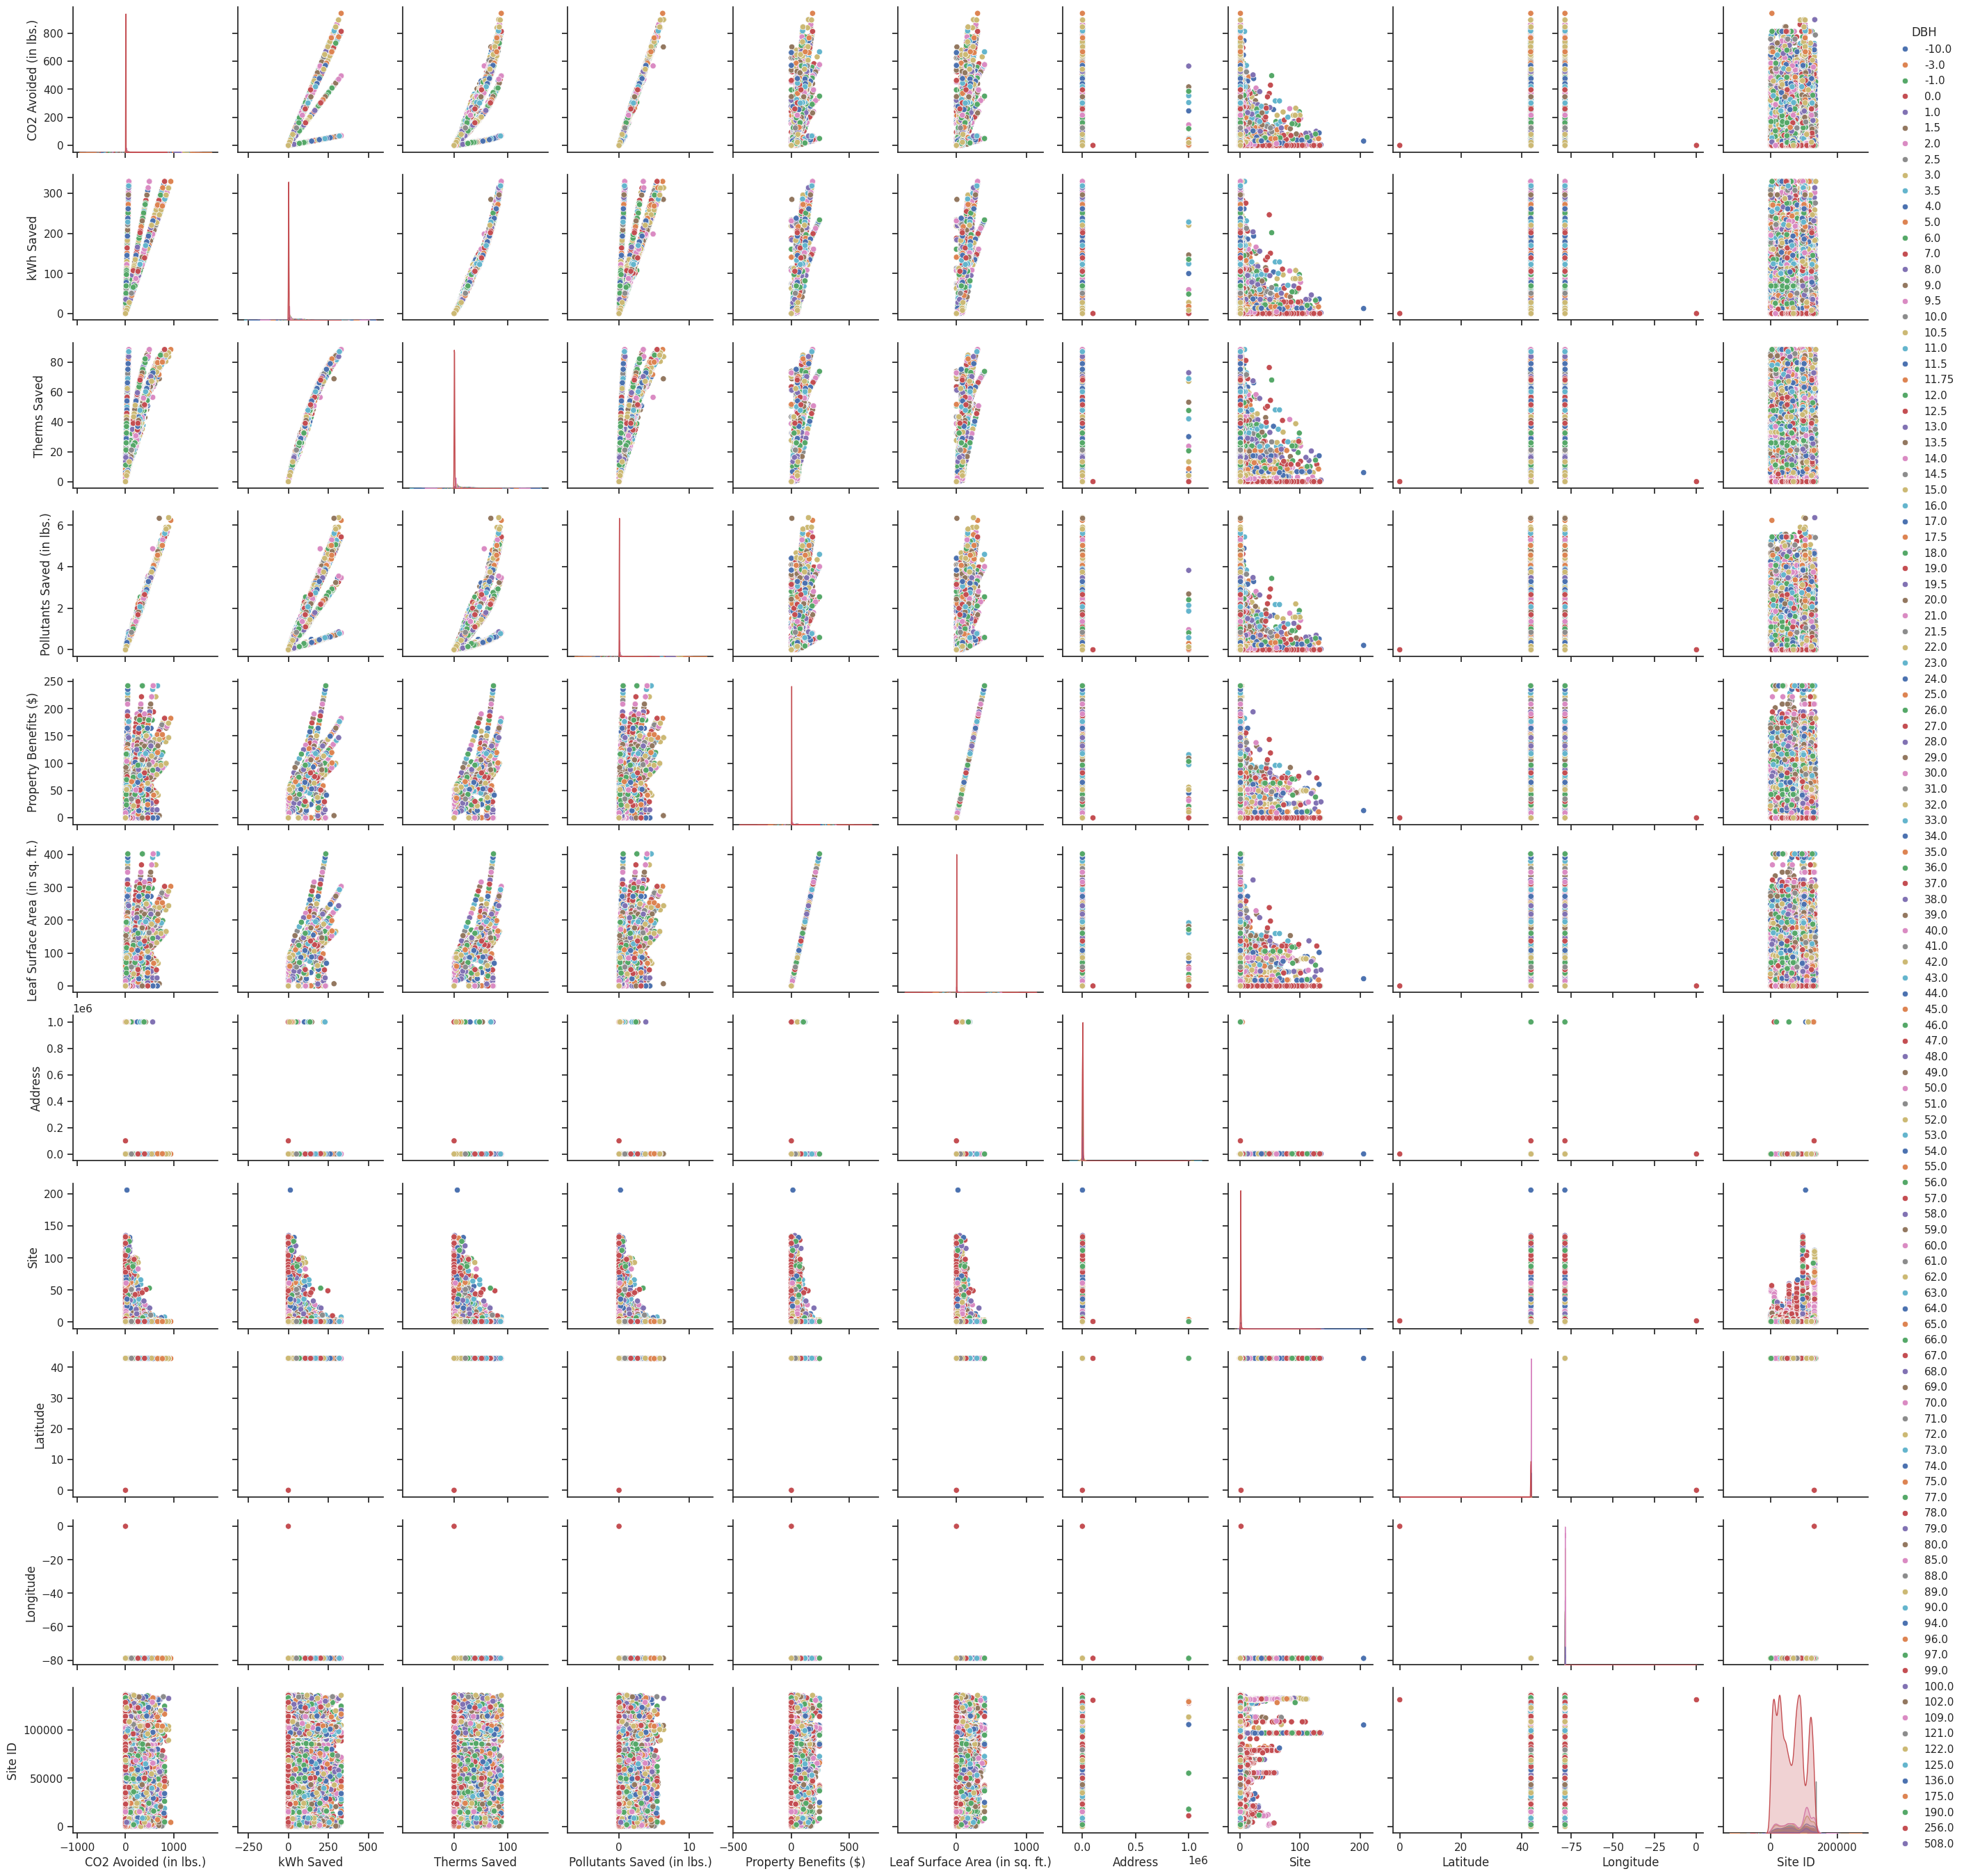

In [ ]:
# reference
#  https://www.geeksforgeeks.org/machine-learning/seaborn-style-and-color/
# https://seaborn.pydata.org/examples/scatterplot_matrix.html
# https://seaborn.pydata.org/generated/seaborn.pairplot.html#seaborn-pairplot
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="ticks")


sns.pairplot(df,palette="deep",hue='DBH')
plt.show()




/tmp/ipython-input-1916362628.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Location Type', y='DBH',


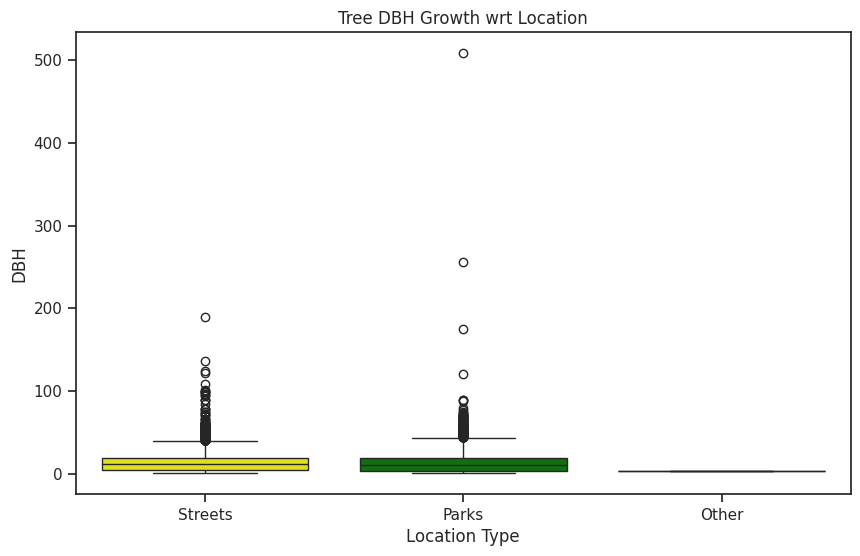

In [ ]:

# reference - https://seaborn.pydata.org/generated/seaborn.scatterplot.html#seaborn-scatterplot
# filter using DBH count > 0
processedData = df[df['DBH'] > 0].copy()

# Let's consider the location as Park, street and for everything else other
def filterLocations(row):
  # row['Park Name'].notnull() not working
    if pd.notna(row['Park Name']) and row['Park Name'] != '0' and row['Park Name'] != '' :
        return 'Parks'
    elif pd.notna(row['Street']) and row['Street'] != '' and row['Street'] != '0':
        return 'Streets'
    else:
        return 'Other'

processedData['Location Type'] = processedData.apply(filterLocations, axis=1)


plt.figure(figsize=(10,6))

palette={"Parks" : "Green","Streets" : "yellow", "Other" : "blue"}
sns.boxplot(x='Location Type', y='DBH',
            data=processedData,
            palette=palette
            )
plt.title('Tree DBH Growth wrt Location')
plt.ylabel('DBH')
plt.show()




/tmp/ipython-input-3877662671.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Council District', y='DBH', data=DbhMean,palette='mako')


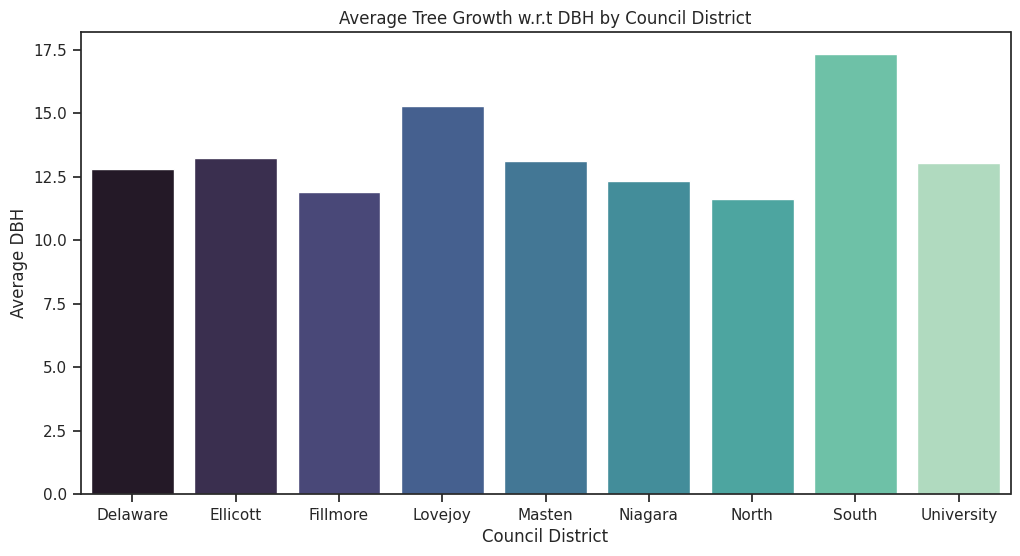

In [ ]:
# Reference https://seaborn.pydata.org/generated/seaborn.boxplot.html#seaborn.boxplot
# Average DBH by Council District

getDBHGrouped = processedData.groupby('Council District')
DbhMean = getDBHGrouped['DBH'].mean()
DbhMean = DbhMean.reset_index()


plt.figure(figsize=(12,6))
sns.barplot(x='Council District', y='DBH', data=DbhMean,palette='mako')
plt.title('Average Tree Growth w.r.t DBH by Council District')
plt.ylabel('Average DBH')
plt.xlabel('Council District')
plt.show()

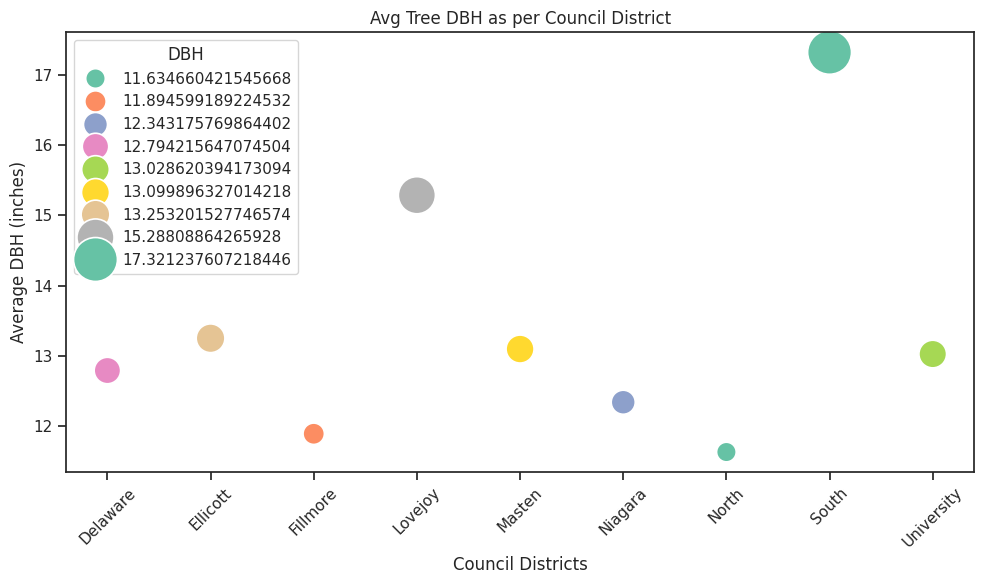

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=DbhMean,
    x='Council District',
    y='DBH',
    size='DBH',
    hue='DBH',
    sizes=(200, 1000),
    palette='Set2', # reference https://seaborn.pydata.org/tutorial/color_palettes.html
    legend='full'

)

plt.title('Avg Tree DBH as per Council Districts')
plt.xlabel('Council Districts')
plt.ylabel('Average DBH -inches')
plt.xticks(rotation=45) # reference - https://matplotlib.org/stable/gallery/ticks/ticklabels_rotation.html
plt.tight_layout() # reference - https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.tight_layout.html
plt.show()


# New Section